# Training a multi-class classifier (Mini-batch GD, B) - PyTorch Version for MNIST

We train with mini-batch gradient descent (batch size B) using PyTorch with hooks to capture gradients and intermediate computations for multi-class classification.

Using device: cuda
Dataset: 900 samples, 784 features, 3 classes
Class distribution: tensor([300, 300, 300], device='cuda:0')
Data shape: X=torch.Size([900, 784]), y=torch.Size([900])
Feature dimension (flattened images): 784


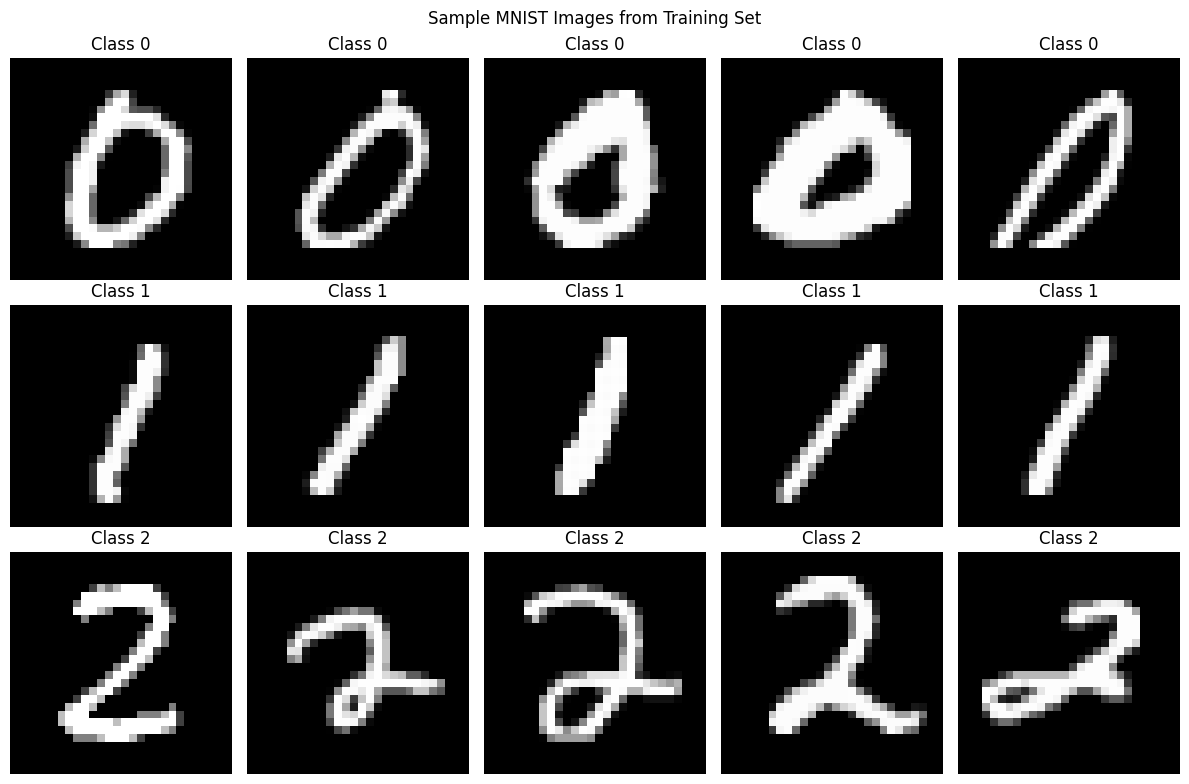

Initial parameters:
Weight shape: torch.Size([3, 784])
Bias shape: torch.Size([3])
Epoch 0: Loss = 0.1441, Acc = 0.9744
Epoch 100: Loss = 0.0100, Acc = 1.0000
Epoch 200: Loss = 0.0049, Acc = 1.0000
Epoch 300: Loss = 0.0033, Acc = 1.0000
Epoch 400: Loss = 0.0025, Acc = 1.0000
Epoch 500: Loss = 0.0020, Acc = 1.0000
Epoch 600: Loss = 0.0017, Acc = 1.0000
Epoch 700: Loss = 0.0015, Acc = 1.0000
Epoch 800: Loss = 0.0013, Acc = 1.0000
Epoch 900: Loss = 0.0011, Acc = 1.0000

Learned parameters (PyTorch mini-batch GD):
Weight shape: torch.Size([3, 784])
Bias shape: torch.Size([3])
Final CCE loss: 0.001029
Training Accuracy: 100.00%
Test Loss: 0.083383
Test Accuracy: 97.78%


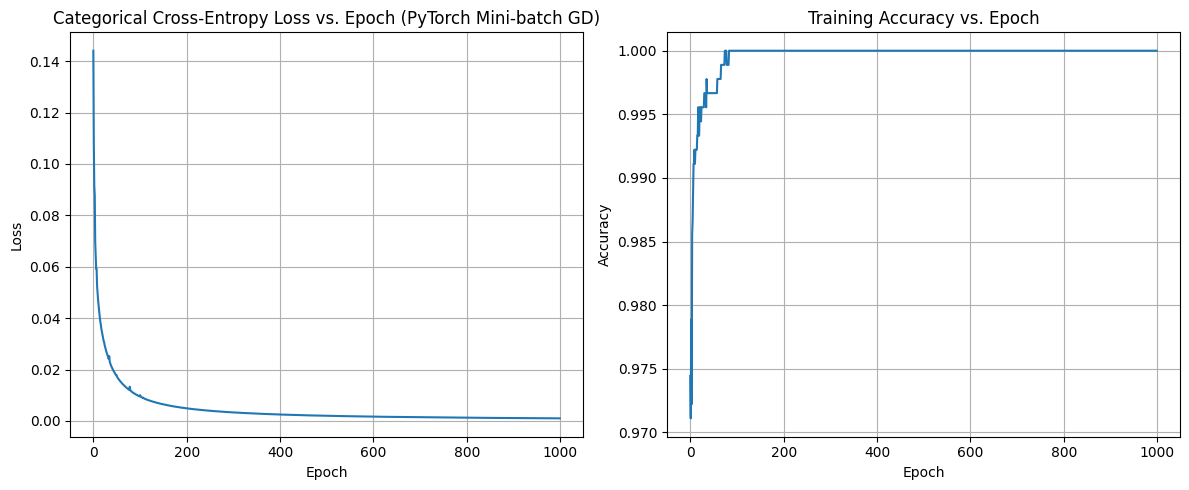

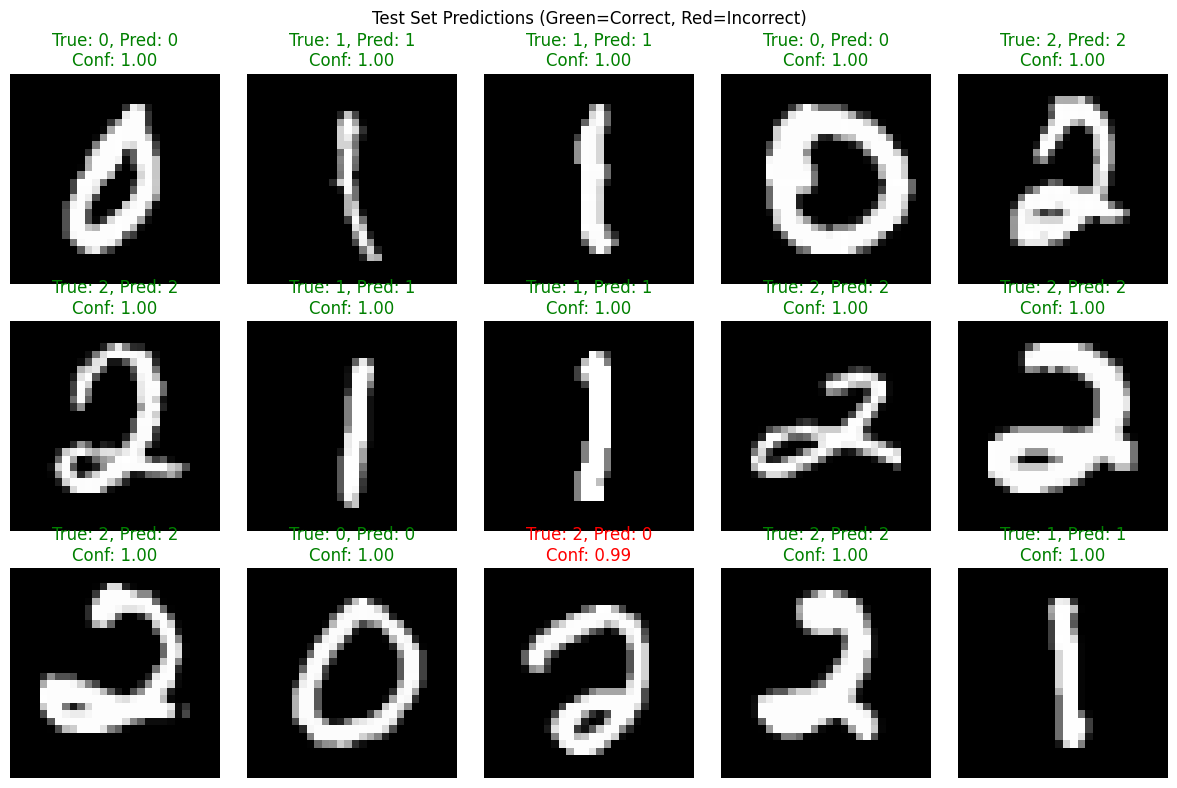


Probe point: MNIST image (flattened 784D vector)
Target class: 1
Current probabilities at probe: [9.3523250e-04 2.1724732e-04 9.9884748e-01]
Current prob for target class 1: 0.0002


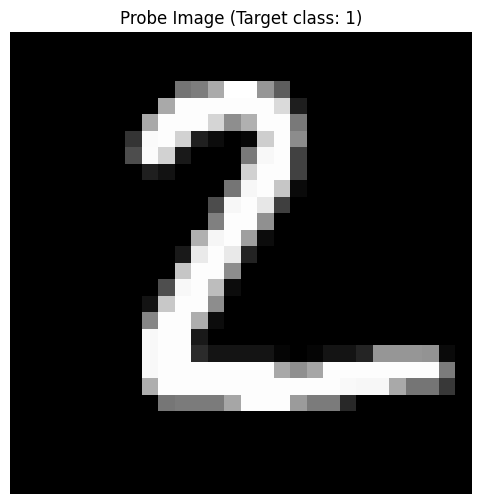

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from torch.autograd import grad
from torchvision import datasets, transforms

B = 32  # batch size
RANDOM_SEED = 49

# Set device and reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Using device: {device}")

# ---- 1) Load real MNIST data ----
# Transform for MNIST: convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Download and load MNIST dataset
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

# For this experiment, let's use a subset of MNIST with only 3 classes (0, 1, 2)
def filter_mnist_classes(dataset, classes=[0, 1, 2]):
    """Filter dataset to only include specified classes"""
    indices = []
    targets = []
    data = []
    
    for i, (img, label) in enumerate(dataset):
        if label in classes:
            indices.append(i)
            targets.append(classes.index(label))  # Remap to 0, 1, 2
            data.append(img.flatten())  # Flatten 28x28 to 784
    
    return torch.stack(data), torch.tensor(targets)

# Filter to 3 classes and take a subset for faster training
n_classes = 3
target_classes = [0, 1, 2]
X_train, y_train = filter_mnist_classes(train_dataset, target_classes)
X_test, y_test = filter_mnist_classes(test_dataset, target_classes)

# Take subset for demonstration (300 samples per class)
samples_per_class = 300
subset_indices = []
for class_idx in range(n_classes):
    class_mask = y_train == class_idx
    class_indices = torch.where(class_mask)[0][:samples_per_class]
    subset_indices.extend(class_indices.tolist())

subset_indices = torch.tensor(subset_indices)
X = X_train[subset_indices]
y = y_train[subset_indices]

# Shuffle the dataset
perm = torch.randperm(len(X))
X = X[perm]
y = y[perm]

N, D = X.shape  # D = 784 (28*28)

# Convert to device
X_tensor = X.to(device)
y_tensor = y.to(device)

print(f"Dataset: {N} samples, {D} features, {n_classes} classes")
print(f"Class distribution: {torch.bincount(y_tensor)}")
print(f"Data shape: X={X.shape}, y={y.shape}")
print(f"Feature dimension (flattened images): {D}")

# Visualize some examples from each class
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for class_idx in range(n_classes):
    class_mask = y == class_idx
    class_samples = X[class_mask][:5]  # Take first 5 samples of each class
    
    for i in range(5):
        img = class_samples[i].reshape(28, 28)
        axes[class_idx, i].imshow(img, cmap='gray')
        axes[class_idx, i].set_title(f'Class {target_classes[class_idx]}')
        axes[class_idx, i].axis('off')

plt.suptitle('Sample MNIST Images from Training Set')
plt.tight_layout()
plt.show()

# ---- 2) Define PyTorch Multi-class Logistic Regression Model for MNIST ----
class MultiClassLogisticRegression(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MultiClassLogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, num_classes)
        
        # Initialize with small weights for MNIST
        nn.init.normal_(self.linear.weight, mean=0, std=0.01)
        nn.init.zeros_(self.linear.bias)
    
    def forward(self, x):
        return self.linear(x)

# Create model for MNIST (784 -> 3 classes)
model = MultiClassLogisticRegression(D, n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

print(f"Initial parameters:")
print(f"Weight shape: {model.linear.weight.data.shape}")
print(f"Bias shape: {model.linear.bias.data.shape}")

# ---- 3) Training with mini-batch GD ----
epochs = 1000  # Reduced epochs for MNIST

loss_history = []
acc_history = []

# Create dataset and dataloader
dataset = TensorDataset(X_tensor, y_tensor)

for epoch in range(epochs):
    # Shuffle data each epoch
    indices = torch.randperm(N)
    X_epoch = X_tensor[indices]
    y_epoch = y_tensor[indices]
    
    # Mini-batch training
    for start in range(0, N, B):
        end = min(start + B, N)
        X_batch = X_epoch[start:end]
        y_batch = y_epoch[start:end]
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
    
    # Track full-data loss and accuracy
    with torch.no_grad():
        full_outputs = model(X_tensor)
        full_loss = criterion(full_outputs, y_tensor)
        loss_history.append(full_loss.item())
        
        # Accuracy
        _, predicted = torch.max(full_outputs, 1)
        accuracy = (predicted == y_tensor).float().mean().item()
        acc_history.append(accuracy)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss_history[-1]:.4f}, Acc = {acc_history[-1]:.4f}")

# Final metrics
with torch.no_grad():
    final_outputs = model(X_tensor)
    _, predictions = torch.max(final_outputs, 1)
    accuracy = (predictions == y_tensor).float().mean().item()

print("\nLearned parameters (PyTorch mini-batch GD):")
print(f"Weight shape: {model.linear.weight.data.shape}")
print(f"Bias shape: {model.linear.bias.data.shape}")
print(f"Final CCE loss: {loss_history[-1]:.6f}")
print(f"Training Accuracy: {accuracy*100:.2f}%")

# Evaluate on test set
X_test_tensor = X_test.to(device)
y_test_tensor = y_test.to(device)

with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)
    _, test_predictions = torch.max(test_outputs, 1)
    test_accuracy = (test_predictions == y_test_tensor).float().mean().item()

print(f"Test Loss: {test_loss.item():.6f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(loss_history)
ax1.set_title("Categorical Cross-Entropy Loss vs. Epoch (PyTorch Mini-batch GD)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

ax2.plot(acc_history)
ax2.set_title("Training Accuracy vs. Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)

plt.tight_layout()
plt.show()

# Visualize some test predictions
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
test_indices = torch.randperm(len(X_test))[:15]  # Random test samples

with torch.no_grad():
    for i, idx in enumerate(test_indices):
        row = i // 5
        col = i % 5
        
        img = X_test[idx].reshape(28, 28)
        true_label = target_classes[y_test[idx]]
        
        # Get model prediction
        pred_logits = model(X_test[idx].unsqueeze(0).to(device))
        pred_probs = F.softmax(pred_logits, dim=1)[0]
        pred_class = torch.argmax(pred_probs).item()
        pred_label = target_classes[pred_class]
        confidence = pred_probs[pred_class].item()
        
        axes[row, col].imshow(img, cmap='gray')
        color = 'green' if pred_label == true_label else 'red'
        axes[row, col].set_title(f'True: {true_label}, Pred: {pred_label}\nConf: {confidence:.2f}', 
                                color=color)
        axes[row, col].axis('off')

plt.suptitle('Test Set Predictions (Green=Correct, Red=Incorrect)')
plt.tight_layout()
plt.show()

# Store original parameters for later use
w_orig = model.linear.weight.data.clone()
b_orig = model.linear.bias.data.clone()

# ---- Probe (x*, y*) ----
# For MNIST, let's create a probe point by taking a real MNIST image
# and slightly modifying it, or use a test sample
test_idx = 0  # Use first test sample as probe
x_star = X_test[test_idx].to(device)  # This is a real MNIST image (flattened)
class_star = 1  # Target class

print(f"\nProbe point: MNIST image (flattened 784D vector)")
print(f"Target class: {class_star}")

# Current prediction at probe
with torch.no_grad():
    logits_star = model(x_star.unsqueeze(0))
    probs_star = F.softmax(logits_star, dim=1)[0]
    print(f"Current probabilities at probe: {probs_star.cpu().numpy()}")
    print(f"Current prob for target class {class_star}: {probs_star[class_star].item():.4f}")

# Visualize the probe image
plt.figure(figsize=(6, 6))
probe_image = x_star.cpu().numpy().reshape(28, 28)
plt.imshow(probe_image, cmap='gray')
plt.title(f'Probe Image (Target class: {class_star})')
plt.axis('off')
plt.show()

# Batchwise norm-budget perturbation (PGD, optimizer-aware, B) - PyTorch with Hooks for Multi-class

In [2]:
import torch
import torch.nn.functional as F
from torch.autograd import grad
import matplotlib.pyplot as plt


def grad_f_logprob_multiclass(x_star, class_star, model):
    """Compute ∇_θ f where f is the log probability of the target class"""
    model.zero_grad()
    
    # Forward pass
    logits_star = model(x_star.unsqueeze(0))
    log_probs = F.log_softmax(logits_star, dim=1)
    log_prob_target = log_probs[0, class_star]
    
    # Compute gradient w.r.t. parameters
    grad_params = grad(log_prob_target, model.parameters(), retain_graph=True)
    
    # Flatten gradients
    grad_w = grad_params[0].flatten()  # (D * n_classes,)
    grad_b = grad_params[1]            # (n_classes,)
    
    return torch.cat([grad_w, grad_b], dim=0)  # (D * n_classes + n_classes,)

# Cross-Jacobian J = ∇_x ∇_θ ℓ for multi-class logistic regression
def cross_jacobian_x_theta_multiclass(x, y_label, model):
    """Compute ∇_x ∇_θ ℓ using PyTorch autograd for multi-class"""
    x = x.clone().detach().requires_grad_(True)
    model.zero_grad()
    
    # Forward pass
    output = model(x.unsqueeze(0))
    
    # Cross entropy loss for this single example
    loss = F.cross_entropy(output, y_label.unsqueeze(0), reduction='none')
    
    # First-order gradients w.r.t. parameters
    grad_theta = grad(loss, model.parameters(), create_graph=True, retain_graph=True)
    grad_w, grad_b = grad_theta[0].flatten(), grad_theta[1]
    grad_theta_concat = torch.cat([grad_w, grad_b])
    
    # Cross derivatives: ∇_x (∇_θ ℓ)
    cross_jacobian = []
    for i in range(len(grad_theta_concat)):
        if grad_theta_concat[i].requires_grad:
            cross_grad = grad(grad_theta_concat[i], x, retain_graph=True, allow_unused=True)[0]
            if cross_grad is not None:
                cross_jacobian.append(cross_grad)
            else:
                cross_jacobian.append(torch.zeros_like(x))
        else:
            cross_jacobian.append(torch.zeros_like(x))
    
    return torch.stack(cross_jacobian)  # ((D * n_classes + n_classes) × D)

# Projection operators
def proj_linf(x0, x_candidate, eps):
    return torch.clamp(x_candidate, x0 - eps, x0 + eps)

def proj_l2(x0, x_candidate, eps):
    d = x_candidate - x0
    n = torch.norm(d, p=2)
    if n <= eps or n == 0:
        return x_candidate
    return x0 + d * (eps / n)

# Quick mini-batch refit for multi-class
def train_minibatch_multiclass(X, y, lr=0.01, epochs=200, B=32):
    """Train a fresh model on the given data using mini-batch SGD"""
    n_classes = len(torch.unique(y))
    model_new = MultiClassLogisticRegression(X.shape[1], n_classes).to(device)
    optimizer_new = optim.SGD(model_new.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    N = X.shape[0]
    for ep in range(epochs):
        indices = torch.randperm(N, device=device)
        X_ep = X[indices]
        y_ep = y[indices]
        
        for start in range(0, N, B):
            end = min(start + B, N)
            Xb = X_ep[start:end]
            yb = y_ep[start:end]
            
            optimizer_new.zero_grad()
            outputs = model_new(Xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer_new.step()
    
    return model_new

# ----------------------------
# Strategy: take the next contiguous B examples after a fresh shuffle.
# For MNIST, we'll work with the existing batch selection
# ----------------------------
perm2 = torch.randperm(N, device=device)
S_idx = perm2[:B]
print("\nBatch indices S =", S_idx.tolist())

# ----------------------------
# PGD settings (per-example norm budget) - adapted for MNIST
# ----------------------------
EPSILON = 0.1      # norm radius (smaller for MNIST due to normalization)
ALPHA   = 0.02     # step size (smaller for stability)
P_NORM  = "inf"    # "inf" or "2"
N_STEPS = int(torch.ceil(torch.tensor(EPSILON / ALPHA)).item()) if P_NORM=="inf" else 10

print(f"PGD settings: ε={EPSILON}, α={ALPHA}, norm={P_NORM}, steps={N_STEPS}")

# ----------------------------
# Compute optimizer-aware directions G_j = -(η/B) J_j^T ∇_θ f
# ----------------------------
eta = 0.01   # learning rate used in training loop
g_f = grad_f_logprob_multiclass(x_star, class_star, model)  # (D * n_classes + n_classes,)

print(f"Gradient of objective shape: {g_f.shape}")

X0_batch = X_tensor[S_idx].clone().detach()
y_batch = y_tensor[S_idx].clone().detach()
X_adv = X0_batch.clone().detach()

print(f"\nStarting PGD optimization...")
for step in range(N_STEPS):
    if step % 2 == 0:
        print(f"  PGD step {step}/{N_STEPS}")
    
    for j_local in range(len(S_idx)):
        j = S_idx[j_local]
        xj0 = X0_batch[j_local]
        yj = y_batch[j_local]

        # J_j at current params
        Jj = cross_jacobian_x_theta_multiclass(X_adv[j_local], yj, model)  # ((D * n_classes + n_classes) × D)

        # G_j = -(η/B) * J_j^T * ∇_θ f
        Gj = -(eta / B) * (Jj.T @ g_f)  # (D,)

        # PGD step + projection
        if P_NORM == "inf":
            step_vec = ALPHA * torch.sign(Gj)
            cand = X_adv[j_local] + step_vec
            X_adv[j_local] = proj_linf(xj0, cand, EPSILON)
        else:
            gnorm = torch.norm(Gj, p=2) + 1e-12
            step_vec = ALPHA * (Gj / gnorm)
            cand = X_adv[j_local] + step_vec
            X_adv[j_local] = proj_l2(xj0, cand, EPSILON)

# Replace the B points with their crafted versions
X_pert = X_tensor.clone().detach()  # Detach to avoid gradient graph issues
X_pert[S_idx] = X_adv.detach()      # Ensure X_adv is also detached

print(f"\nPGD optimization complete.")

# ----------------------------
# Evaluate f(θ) before/after retraining (mini-batch regime)
# ----------------------------
with torch.no_grad():
    logits_before = model(x_star.unsqueeze(0))
    probs_before = F.softmax(logits_before, dim=1)[0]
    f_before = probs_before[class_star].item()
    logf_before = torch.log(probs_before[class_star] + 1e-12).item()

print(f"\nRetraining model with perturbed data...")
model_new = train_minibatch_multiclass(X_pert, y_tensor, lr=0.01, epochs=300, B=B)

with torch.no_grad():
    logits_after = model_new(x_star.unsqueeze(0))
    probs_after = F.softmax(logits_after, dim=1)[0]
    f_after = probs_after[class_star].item()
    logf_after = torch.log(probs_after[class_star] + 1e-12).item()

print(f"\nProbe point: MNIST image (784D flattened), target class: {class_star}")
print(f"P(class {class_star}) before = {f_before:.6f} ; after = {f_after:.6f} ; Δ = {f_after - f_before:+.6f}")
print(f"log P(class {class_star}) before = {logf_before:.6f} ; after = {logf_after:.6f} ; Δ = {logf_after - logf_before:+.6f}")

# ----------------------------
# Visualize the probe point and some perturbed examples
# ----------------------------
fig, axes = plt.subplots(3, 5, figsize=(15, 10))

# Show probe point
axes[0, 0].imshow(x_star.cpu().numpy().reshape(28, 28), cmap='gray')
axes[0, 0].set_title(f'Probe Point\n(Target: Class {class_star})')
axes[0, 0].axis('off')

# Show some original batch points
for i in range(4):
    if i < len(X0_batch):
        img = X0_batch[i].cpu().numpy().reshape(28, 28)
        axes[0, i+1].imshow(img, cmap='gray')
        axes[0, i+1].set_title(f'Original {i}\n(Class {y_batch[i].item()})')
        axes[0, i+1].axis('off')

# Show corresponding perturbed points
for i in range(4):
    if i < len(X_adv):
        img = X_adv[i].cpu().numpy().reshape(28, 28)
        axes[1, i+1].imshow(img, cmap='gray')
        axes[1, i+1].set_title(f'Perturbed {i}')
        axes[1, i+1].axis('off')

# Show differences
axes[1, 0].imshow(torch.zeros(28, 28), cmap='gray')
axes[1, 0].set_title('Differences')
axes[1, 0].axis('off')

for i in range(4):
    if i < len(X_adv):
        diff = (X_adv[i] - X0_batch[i]).cpu().numpy().reshape(28, 28)
        axes[2, i+1].imshow(diff, cmap='RdBu', vmin=-EPSILON, vmax=EPSILON)
        axes[2, i+1].set_title(f'Diff {i}')
        axes[2, i+1].axis('off')

# Show magnitude of changes
axes[2, 0].text(0.5, 0.5, f'PGD Results:\nε={EPSILON}\nα={ALPHA}\nsteps={N_STEPS}', 
                ha='center', va='center', transform=axes[2, 0].transAxes)
axes[2, 0].axis('off')

plt.suptitle(f'MNIST Batch Perturbation Results\nObjective change: {logf_after - logf_before:+.4f}')
plt.tight_layout()
plt.show()

# Keep updated params/data if you want to continue
model = model_new
X_tensor = X_pert


Batch indices S = [427, 346, 160, 82, 894, 345, 48, 565, 658, 94, 192, 612, 807, 767, 773, 678, 609, 677, 198, 639, 509, 229, 187, 870, 79, 403, 22, 882, 353, 214, 790, 495]
PGD settings: ε=0.1, α=0.02, norm=inf, steps=5
Gradient of objective shape: torch.Size([2355])

Starting PGD optimization...
  PGD step 0/5
  PGD step 2/5
  PGD step 4/5


KeyboardInterrupt: 

# Multi-class influence function with PyTorch

Probe point: [1.  1.5]
Target class: 1
Current probabilities at probe: [0.22293177 0.31552494 0.46154332]
Current prob for target class 1: 0.3155

Computing Hessian...
Hessian shape: torch.Size([9, 9])
Gradient shape: torch.Size([9])
Solving for influence direction...
Computing influence scores...
Influence scores computed. Range: [-0.048320, 0.037747]
Sum of influence scores: 2.497046e+00


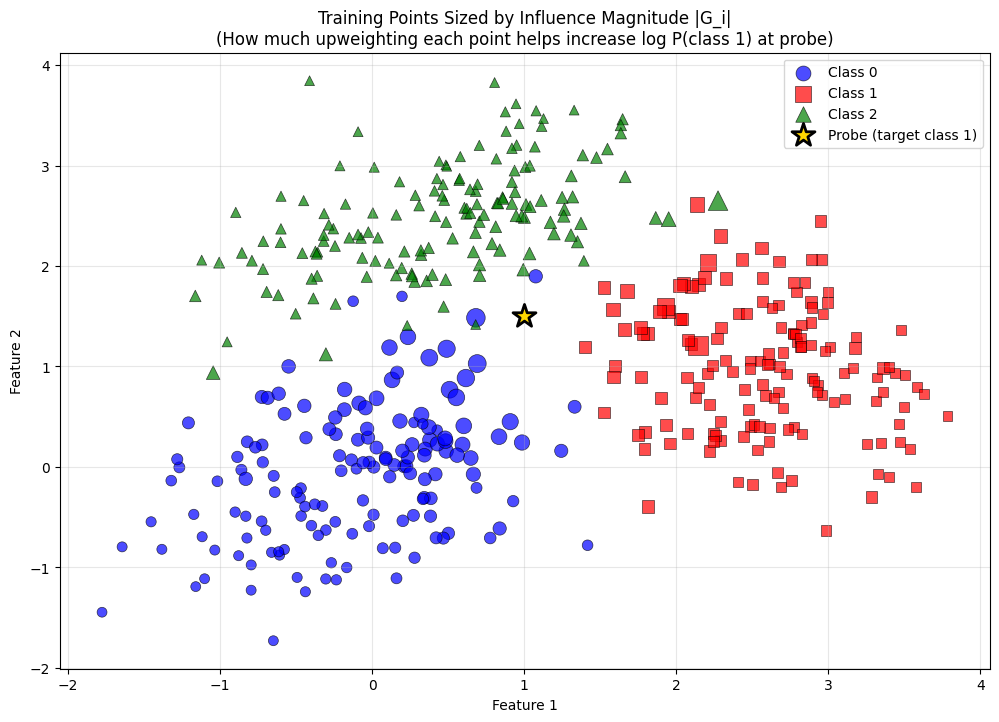

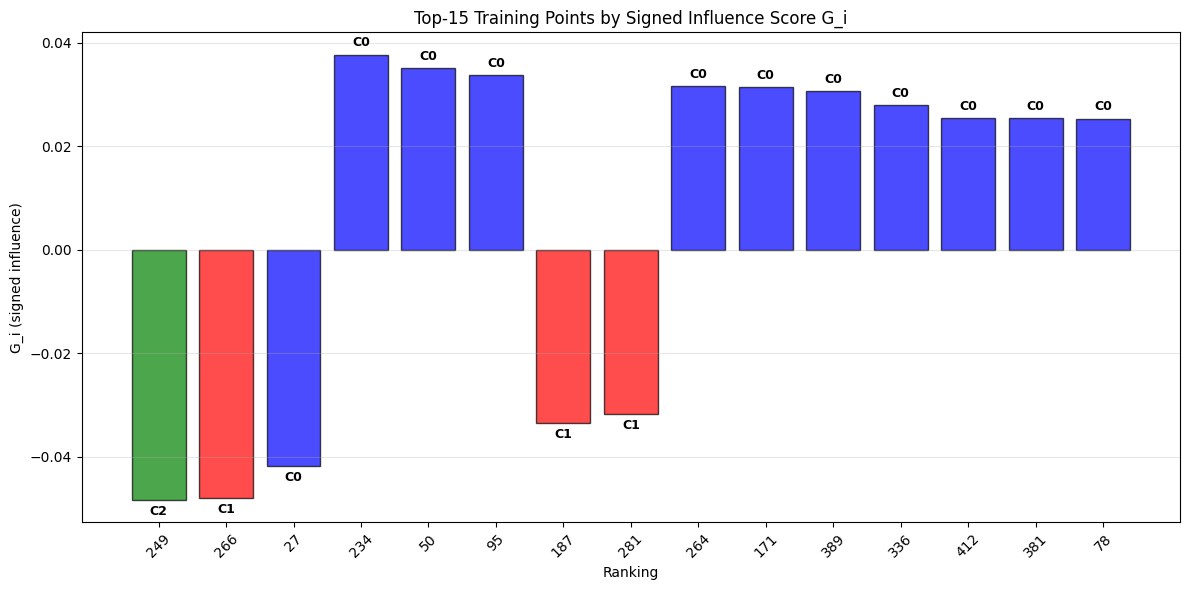


Top 5 most influential points (by magnitude):
1. Point 249: class=2, G_i=-0.048320, coords=(2.276, 2.651)
2. Point 266: class=1, G_i=-0.047878, coords=(2.146, 1.209)
3. Point 27: class=0, G_i=-0.041811, coords=(0.683, 1.485)
4. Point 234: class=0, G_i=0.037747, coords=(0.692, 1.029)
5. Point 50: class=0, G_i=0.035187, coords=(0.617, 0.885)


In [ ]:
# Influence-style calculation for softmax regression with CCE using PyTorch.
# We'll compute the influence of upweighting training points on the log-probability
# of a specific class for a probe point.

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad

def compute_multiclass_hessian_torch(model, X, y, lam=1e-3):
    """Compute Hessian for softmax regression using PyTorch"""
    N = X.shape[0]
    D = X.shape[1]
    n_classes = model.linear.out_features
    
    # Total parameter dimension
    param_dim = D * n_classes + n_classes
    
    H = torch.zeros((param_dim, param_dim), device=device)
    
    for i in range(N):
        x_i = X[i:i+1]  # Keep batch dimension
        
        # Get probabilities for this point
        with torch.no_grad():
            logits_i = model(x_i)
            probs_i = F.softmax(logits_i, dim=1)[0]  # (n_classes,)
        
        # Augmented features [x_i, 1]
        x_i_aug = torch.cat([x_i.squeeze(), torch.ones(1, device=device)])  # (D+1,)
        
        # Compute Hessian contribution for this point
        for k in range(n_classes):
            for j in range(n_classes):
                k_start, k_end = k * (D + 1), (k + 1) * (D + 1)
                j_start, j_end = j * (D + 1), (j + 1) * (D + 1)
                
                if k == j:
                    coeff = probs_i[k] * (1 - probs_i[k])
                else:
                    coeff = -probs_i[k] * probs_i[j]
                
                H[k_start:k_end, j_start:j_end] += coeff * torch.outer(x_i_aug, x_i_aug)
    
    H /= N
    # Add regularization
    H += lam * torch.eye(param_dim, device=device)
    return H

# Choose probe point and target class (same as before)
print(f"Probe point: {x_star.cpu().numpy()}")
print(f"Target class: {class_star}")

# Current prediction at probe
with torch.no_grad():
    logits_star = model(x_star.unsqueeze(0))
    probs_star = F.softmax(logits_star, dim=1)[0]
    print(f"Current probabilities at probe: {probs_star.cpu().numpy()}")
    print(f"Current prob for target class {class_star}: {probs_star[class_star].item():.4f}")

# Compute Hessian
print("\nComputing Hessian...")
H = compute_multiclass_hessian_torch(model, X_tensor, y_tensor)
print(f"Hessian shape: {H.shape}")

# Gradient of log P(class_star | x_star) w.r.t. parameters
g_f = grad_f_logprob_multiclass(x_star, class_star, model)
print(f"Gradient shape: {g_f.shape}")

# Solve for influence direction: v = H^{-1} * grad_f
print("Solving for influence direction...")
v = torch.linalg.solve(H, g_f)

# Compute influence scores G_i for each training point
print("Computing influence scores...")
G = torch.zeros(N, device=device)

for i in range(N):
    x_i = X_tensor[i]
    y_i = y_tensor[i]
    
    # Current prediction for point i
    with torch.no_grad():
        logits_i = model(x_i.unsqueeze(0))
        probs_i = F.softmax(logits_i, dim=1)[0]
    
    # Gradient of loss w.r.t. parameters for point i
    x_i_aug = torch.cat([x_i, torch.ones(1, device=device)])  # (D+1,)
    
    grad_L_i = torch.zeros(D * n_classes + n_classes, device=device)
    
    for k in range(n_classes):
        k_start = k * (D + 1)
        k_end = (k + 1) * (D + 1)
        
        if k == y_i:
            # True class: (p_k - 1) * x_i
            grad_L_i[k_start:k_end] = (probs_i[k] - 1.0) * x_i_aug
        else:
            # Other classes: p_k * x_i
            grad_L_i[k_start:k_end] = probs_i[k] * x_i_aug
    
    # Influence score
    G[i] = -(grad_L_i @ v) / N

G_np = G.cpu().numpy()
print(f"Influence scores computed. Range: [{G_np.min():.6f}, {G_np.max():.6f}]")
print(f"Sum of influence scores: {G_np.sum():.6e}")

# ---- Visualizations ----
# 1) Scatter plot with point sizes proportional to |G_i|
plt.figure(figsize=(12, 8))

for class_idx in range(n_classes):
    mask = y_np == class_idx
    X_class = X_np[mask]
    G_class = G_np[mask]
    
    # Normalize sizes for plotting (min size 20, max size 200)
    if np.max(np.abs(G_np)) > 0:
        sizes = 50 + 150 * (np.abs(G_class) / np.max(np.abs(G_np)))
    else:
        sizes = np.full(len(G_class), 50)
    
    plt.scatter(X_class[:, 0], X_class[:, 1], 
               s=sizes, c=class_colors[class_idx], marker=class_markers[class_idx],
               alpha=0.7, edgecolors='black', linewidth=0.5,
               label=f'Class {class_idx}')

# Add probe point
plt.scatter(x_star_np[0], x_star_np[1], marker='*', s=300, 
           c='gold', edgecolors='black', linewidth=2,
           label=f'Probe (target class {class_star})', zorder=10)

plt.title(f'Training Points Sized by Influence Magnitude |G_i|\n'
          f'(How much upweighting each point helps increase log P(class {class_star}) at probe)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2) Bar plot of top-K influences
K = 15
top_indices = np.argsort(-np.abs(G_np))[:K]

plt.figure(figsize=(12, 6))
colors = [class_colors[y_np[i]] for i in top_indices]
bars = plt.bar(range(K), G_np[top_indices], color=colors, alpha=0.7, edgecolor='black')

# Add class labels on bars
for i, (bar, idx) in enumerate(zip(bars, top_indices)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + np.sign(height)*0.001,
             f'C{y_np[idx]}', ha='center', va='bottom' if height >= 0 else 'top',
             fontsize=9, fontweight='bold')

plt.title(f'Top-{K} Training Points by Signed Influence Score G_i')
plt.xlabel('Ranking')
plt.ylabel('G_i (signed influence)')
plt.xticks(range(K), [f'{i}' for i in top_indices], rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nTop 5 most influential points (by magnitude):")
for i, idx in enumerate(top_indices[:5]):
    print(f"{i+1}. Point {idx}: class={y_np[idx]}, G_i={G_np[idx]:.6f}, "
          f"coords=({X_np[idx,0]:.3f}, {X_np[idx,1]:.3f})")

# Multi-class Infusion with PyTorch

Now we turn to creating optimal new points for multi-class classification by:
1. Computing scores for each possible (x, class) combination
2. Finding the most helpful new labeled point to add

In [ ]:
# Multi-class infusion: find optimal (x, y) pairs to add to training set
# to maximize log P(target_class | x_star) using PyTorch for MNIST

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad

# Use the same probe point and target class from before
print(f"Probe point: MNIST image (784D flattened vector)")
print(f"Target class: {class_star}")
with torch.no_grad():
    logits_star = model(x_star.unsqueeze(0))
    probs_star = F.softmax(logits_star, dim=1)[0]
    print(f"Current P(class {class_star} | probe) = {probs_star[class_star].item():.4f}")

# For MNIST, instead of creating a grid, we'll sample candidate points from:
# 1. Existing training/test data (with different labels)
# 2. Gaussian noise around existing points
# 3. Interpolations between existing points

LAM = 1e-3
N_CANDIDATES = 1000  # Number of candidate points to evaluate

print(f"Evaluating {N_CANDIDATES} candidate points for MNIST...")

# Compute influence direction v = H^{-1} * grad_f (reuse from before if available)
# For efficiency with high-dimensional MNIST, we'll use the existing Hessian
if 'H' not in locals():
    print("Computing Hessian for MNIST...")
    H = compute_multiclass_hessian_torch(model, X_tensor, y_tensor, LAM)
    print(f"Hessian shape: {H.shape}")

if 'v' not in locals():
    print("Computing influence direction...")
    g_f = grad_f_logprob_multiclass(x_star, class_star, model)
    v = torch.linalg.solve(H, g_f)

# Generate candidate points
X_candidates = []
candidate_sources = []

# 1. Sample from existing training data (we can change their labels)
n_from_train = N_CANDIDATES // 3
train_indices = torch.randperm(len(X_tensor))[:n_from_train]
for idx in train_indices:
    X_candidates.append(X_tensor[idx])
    candidate_sources.append(f"train_{idx}")

# 2. Add Gaussian noise to existing points
n_noise = N_CANDIDATES // 3
noise_indices = torch.randperm(len(X_tensor))[:n_noise]
noise_std = 0.1  # Small noise for MNIST
for idx in noise_indices:
    base_point = X_tensor[idx]
    noisy_point = base_point + torch.randn_like(base_point) * noise_std
    # Clamp to reasonable range for normalized MNIST
    noisy_point = torch.clamp(noisy_point, -3, 3)
    X_candidates.append(noisy_point)
    candidate_sources.append(f"noise_{idx}")

# 3. Interpolations between random pairs
n_interp = N_CANDIDATES - len(X_candidates)
for _ in range(n_interp):
    idx1, idx2 = torch.randperm(len(X_tensor))[:2]
    alpha = torch.rand(1).item()
    interp_point = alpha * X_tensor[idx1] + (1 - alpha) * X_tensor[idx2]
    X_candidates.append(interp_point)
    candidate_sources.append(f"interp_{idx1}_{idx2}")

X_candidates = torch.stack(X_candidates)
print(f"Generated {len(X_candidates)} candidate points")

# For each candidate point and each possible class, compute the score
scores = torch.zeros((len(X_candidates), n_classes), device=device)

print("Computing scores for all candidates...")
for i, x_cand in enumerate(X_candidates):
    if i % 200 == 0:
        print(f"  Progress: {i}/{len(X_candidates)}")
    
    for class_cand in range(n_classes):
        # Gradient of loss w.r.t. parameters if we add (x_cand, class_cand)
        grad_L_cand = grad_L_multiclass_torch(x_cand, class_cand, model)
        
        # Score: how much this point would help (negative because we want to minimize loss)
        scores[i, class_cand] = grad_L_cand @ v

# Find the best (point, class) combination
best_scores_per_point, best_classes_per_point = torch.min(scores, dim=1)
global_best_idx = torch.argmin(best_scores_per_point)
best_point = X_candidates[global_best_idx]
best_class = best_classes_per_point[global_best_idx]
best_score = best_scores_per_point[global_best_idx]

print(f"\nOptimal point to add:")
print(f"Source: {candidate_sources[global_best_idx]}")
print(f"Class: {best_class.item()}")
print(f"Score: {best_score.item():.6f}")

# Convert to numpy for analysis
scores_np = scores.cpu().numpy()
best_scores_np = best_scores_per_point.cpu().numpy()
best_classes_np = best_classes_per_point.cpu().numpy()
best_point_np = best_point.cpu().numpy()

# ---- Visualizations ----
# 1) Histogram of scores by class
fig, axes = plt.subplots(1, n_classes, figsize=(15, 4))
class_colors = ['blue', 'red', 'green']

for k in range(n_classes):
    class_scores = scores_np[:, k]
    axes[k].hist(class_scores, bins=50, alpha=0.7, color=class_colors[k])
    axes[k].set_title(f'Score Distribution for Class {k} Points')
    axes[k].set_xlabel('Score (lower = more helpful)')
    axes[k].set_ylabel('Count')
    axes[k].grid(True, alpha=0.3)
    axes[k].axvline(class_scores.min(), color='red', linestyle='--', 
                   label=f'Best: {class_scores.min():.4f}')
    axes[k].legend()

plt.suptitle('Distribution of Infusion Scores by Class')
plt.tight_layout()
plt.show()

# 2) Show the optimal point as an image
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(best_point_np.reshape(28, 28), cmap='gray')
plt.title(f'Optimal New Point\n(Class {best_class.item()}, Score: {best_score.item():.4f})')
plt.axis('off')

# Compare with the probe point
plt.subplot(1, 3, 2)
plt.imshow(x_star.cpu().numpy().reshape(28, 28), cmap='gray')
plt.title(f'Probe Point\n(Target: Class {class_star})')
plt.axis('off')

# Show difference
plt.subplot(1, 3, 3)
diff_img = (best_point_np - x_star.cpu().numpy()).reshape(28, 28)
plt.imshow(diff_img, cmap='RdBu', vmin=-diff_img.std()*2, vmax=diff_img.std()*2)
plt.title('Difference\n(Optimal - Probe)')
plt.axis('off')
plt.colorbar()

plt.tight_layout()
plt.show()

# 3) Top candidates analysis
print(f"\nTop 10 most helpful candidate points:")
top_indices = torch.argsort(best_scores_per_point)[:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, idx in enumerate(top_indices):
    row = i // 5
    col = i % 5
    
    candidate_img = X_candidates[idx].cpu().numpy().reshape(28, 28)
    candidate_class = best_classes_per_point[idx].item()
    candidate_score = best_scores_per_point[idx].item()
    source = candidate_sources[idx]
    
    axes[row, col].imshow(candidate_img, cmap='gray')
    axes[row, col].set_title(f'#{i+1}: Class {candidate_class}\nScore: {candidate_score:.4f}\n{source[:12]}...', 
                            fontsize=8)
    axes[row, col].axis('off')
    
    print(f"{i+1:2d}. Class {candidate_class}, Score: {candidate_score:.6f}, Source: {source}")

plt.suptitle('Top 10 Most Helpful Candidate Points')
plt.tight_layout()
plt.show()

# 4) Score comparison by class assignment
plt.figure(figsize=(10, 6))
for k in range(n_classes):
    class_mask = best_classes_np == k
    if class_mask.sum() > 0:
        plt.scatter(range(class_mask.sum()), best_scores_np[class_mask], 
                   color=class_colors[k], alpha=0.6, label=f'Class {k}', s=20)

plt.xlabel('Candidate Point Index (sorted by class)')
plt.ylabel('Best Score for Each Point')
plt.title('Optimal Class Assignment and Scores for Candidate Points')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nClass distribution of optimal assignments:")
class_counts = torch.bincount(best_classes_per_point, minlength=n_classes)
for k in range(n_classes):
    pct = 100 * class_counts[k] / len(best_classes_per_point)
    print(f"Class {k}: {class_counts[k]} points ({pct:.1f}%)")

# Store the best point for use in subsequent cells
optimal_x = best_point
optimal_y = best_class
optimal_score = best_score

# Active Multi-class Training Loop with PyTorch

Now we implement an active learning loop that iteratively:
1. Finds the most helpful (x, y) point to add
2. Updates the model parameters
3. Repeats to see how the objective improves

In [ ]:
# ============================================================
# Active loop: pick best new point from candidate set, train, repeat
# Adapted for MNIST high-dimensional data
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad

# ----------------------------
# Config
# ----------------------------
MODE = "second"   # "first" or "second"
LAM = 1e-3
LR = 0.01
NUM_ITERS = 5  # Reduced for MNIST demo
N_CANDIDATES_PER_ITER = 200  # Smaller candidate set per iteration

print(f"Active training mode: {MODE.upper()}")
print(f"Learning rate: {LR}")
print(f"Regularization: {LAM}")
print(f"Candidates per iteration: {N_CANDIDATES_PER_ITER}")

# ----------------------------
# Utilities for MNIST
# ----------------------------
def generate_mnist_candidates(X_current, n_candidates=N_CANDIDATES_PER_ITER):
    """Generate candidate points for MNIST"""
    candidates = []
    sources = []
    
    # Sample existing points (can relabel)
    n_existing = n_candidates // 2
    indices = torch.randperm(len(X_current))[:n_existing]
    for idx in indices:
        candidates.append(X_current[idx])
        sources.append(f"existing_{idx}")
    
    # Add noise to existing points
    n_noise = n_candidates - n_existing
    noise_indices = torch.randperm(len(X_current))[:n_noise]
    for idx in noise_indices:
        base = X_current[idx]
        noisy = base + torch.randn_like(base) * 0.05  # Small noise
        noisy = torch.clamp(noisy, -3, 3)  # Reasonable range
        candidates.append(noisy)
        sources.append(f"noise_{idx}")
    
    return torch.stack(candidates), sources

def compute_scores_mnist(model, x_star, class_star, X_current, y_current, 
                        n_candidates=N_CANDIDATES_PER_ITER, lam=LAM, mode=MODE):
    """Compute scores for MNIST candidates"""
    
    # Generate candidates
    X_candidates, sources = generate_mnist_candidates(X_current, n_candidates)
    
    # Compute influence direction
    g_f = grad_f_logprob_multiclass(x_star, class_star, model)
    
    H_reg = None
    v_dir = g_f.clone()
    if mode == "second":
        H_reg = compute_multiclass_hessian_torch(model, X_current, y_current, lam)
        v_dir = torch.linalg.solve(H_reg, g_f)
    
    # Compute scores
    n_classes = model.linear.out_features
    scores = torch.zeros((len(X_candidates), n_classes), device=device)
    
    for i, x_cand in enumerate(X_candidates):
        for class_cand in range(n_classes):
            gL = grad_L_multiclass_torch(x_cand, class_cand, model)
            scores[i, class_cand] = gL @ v_dir
    
    # Find best class for each candidate
    best_scores, best_classes = torch.min(scores, dim=1)
    
    return X_candidates, sources, scores, best_scores, best_classes, H_reg

def plot_mnist_iteration(X_candidates, sources, scores, best_scores, best_classes,
                        X_data, y_data, model, x_star, class_star,
                        new_point=None, new_class=None, iteration=0, mode=MODE):
    """Plot results for MNIST iteration"""
    
    n_classes = len(torch.unique(y_data))
    class_colors = ['blue', 'red', 'green']
    
    fig = plt.figure(figsize=(18, 12))
    
    # 1) Score distributions
    ax1 = plt.subplot(3, 3, 1)
    for k in range(n_classes):
        class_scores = scores[:, k].cpu().numpy()
        ax1.hist(class_scores, bins=30, alpha=0.6, color=class_colors[k], 
                label=f'Class {k}')
    ax1.set_title(f'Score Distributions ({mode} order)')
    ax1.set_xlabel('Score')
    ax1.set_ylabel('Count')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2) Best candidates visualization
    ax2 = plt.subplot(3, 3, 2)
    top_k = 6
    top_indices = torch.argsort(best_scores)[:top_k]
    
    # Create subplot for top candidates
    for i, idx in enumerate(top_indices):
        row_offset = i // 3
        col_offset = i % 3
        ax_small = plt.subplot(3, 6, 7 + i)  # Start from row 2
        
        candidate_img = X_candidates[idx].cpu().numpy().reshape(28, 28)
        candidate_class = best_classes[idx].item()
        candidate_score = best_scores[idx].item()
        
        ax_small.imshow(candidate_img, cmap='gray')
        ax_small.set_title(f'#{i+1}: C{candidate_class}\n{candidate_score:.3f}', fontsize=8)
        ax_small.axis('off')
    
    # 3) Probe point
    ax3 = plt.subplot(3, 3, 3)
    probe_img = x_star.cpu().numpy().reshape(28, 28)
    ax3.imshow(probe_img, cmap='gray')
    ax3.set_title(f'Probe Point\n(Target: Class {class_star})')
    ax3.axis('off')
    
    # 4) Current predictions on test set
    ax4 = plt.subplot(3, 3, 4)
    with torch.no_grad():
        test_sample_indices = torch.randperm(len(X_test))[:100]
        test_outputs = model(X_test[test_sample_indices].to(device))
        test_preds = torch.argmax(test_outputs, dim=1).cpu()
        test_correct = (test_preds == y_test[test_sample_indices]).float().mean()
    
    ax4.bar(range(n_classes), torch.bincount(test_preds, minlength=n_classes).float(), 
           color=class_colors, alpha=0.7)
    ax4.set_title(f'Test Predictions\nAcc: {test_correct:.3f}')
    ax4.set_xlabel('Predicted Class')
    ax4.set_ylabel('Count')
    
    # 5) Dataset composition
    ax5 = plt.subplot(3, 3, 5)
    train_counts = torch.bincount(y_data, minlength=n_classes)
    ax5.bar(range(n_classes), train_counts.cpu().float(), 
           color=class_colors, alpha=0.7)
    ax5.set_title(f'Training Set\nTotal: {len(y_data)}')
    ax5.set_xlabel('Class')
    ax5.set_ylabel('Count')
    
    # 6) Selected point (if any)
    if new_point is not None:
        ax6 = plt.subplot(3, 3, 6)
        new_img = new_point.cpu().numpy().reshape(28, 28)
        ax6.imshow(new_img, cmap='gray')
        ax6.set_title(f'Selected Point\nClass {new_class}')
        ax6.axis('off')
    
    plt.suptitle(f'MNIST Active Learning - Iteration {iteration} ({mode.upper()})', fontsize=14)
    plt.tight_layout()
    plt.show()

# ----------------------------
# Initialize tracking
# ----------------------------
X_active = X_tensor.clone()
y_active = y_tensor.clone()

# Create fresh model
model_active = MultiClassLogisticRegression(D, n_classes).to(device)
model_active.load_state_dict(model.state_dict())

# Track metrics
logprobs_at_probe = []
test_accuracies = []
iterations_list = []

# Initial metrics
with torch.no_grad():
    logits_initial = model_active(x_star.unsqueeze(0))
    probs_initial = F.softmax(logits_initial, dim=1)[0]
    logprob_initial = torch.log(probs_initial[class_star] + 1e-12).item()
    
    # Test accuracy
    test_outputs = model_active(X_test.to(device))
    test_preds = torch.argmax(test_outputs, dim=1)
    test_acc_initial = (test_preds == y_test.to(device)).float().mean().item()

logprobs_at_probe.append(logprob_initial)
test_accuracies.append(test_acc_initial)
iterations_list.append(0)

print(f"\nInitial log P(class {class_star} | probe) = {logprob_initial:.6f}")
print(f"Initial P(class {class_star} | probe) = {probs_initial[class_star].item():.6f}")
print(f"Initial test accuracy = {test_acc_initial:.4f}")

# ----------------------------
# Main active learning loop
# ----------------------------
for iteration in range(1, NUM_ITERS + 1):
    print(f"\n--- Iteration {iteration} ---")
    
    # Generate candidates and compute scores
    X_candidates, sources, all_scores, best_scores, best_classes, H_reg = \
        compute_scores_mnist(model_active, x_star, class_star, X_active, y_active, 
                           N_CANDIDATES_PER_ITER, LAM, MODE)
    
    # Find globally best candidate
    global_best_idx = torch.argmin(best_scores)
    x_new = X_candidates[global_best_idx]
    y_new = best_classes[global_best_idx]
    score_new = best_scores[global_best_idx]
    
    print(f"Selected candidate: {sources[global_best_idx]}")
    print(f"Selected class: {y_new.item()}")
    print(f"Score: {score_new.item():.6f}")
    
    # Current metrics
    with torch.no_grad():
        logits_current = model_active(x_star.unsqueeze(0))
        probs_current = F.softmax(logits_current, dim=1)[0]
        logprob_current = torch.log(probs_current[class_star] + 1e-12).item()
        
        test_outputs = model_active(X_test.to(device))
        test_preds = torch.argmax(test_outputs, dim=1)
        test_acc_current = (test_preds == y_test.to(device)).float().mean().item()
    
    print(f"Current log P(class {class_star} | probe) = {logprob_current:.6f}")
    print(f"Current test accuracy = {test_acc_current:.4f}")
    
    # Plot current state
    plot_mnist_iteration(X_candidates, sources, all_scores, best_scores, best_classes,
                        X_active, y_active, model_active, x_star, class_star,
                        x_new, y_new.item(), iteration, MODE)
    
    # Update parameters
    update_multiclass_params_torch(model_active, x_new, y_new.item(), H_reg, LR, MODE)
    
    # Add new point to dataset
    X_active = torch.vstack([X_active, x_new.unsqueeze(0)])
    y_active = torch.cat([y_active, y_new.unsqueeze(0)])
    
    # Compute updated metrics
    with torch.no_grad():
        logits_after = model_active(x_star.unsqueeze(0))
        probs_after = F.softmax(logits_after, dim=1)[0]
        logprob_after = torch.log(probs_after[class_star] + 1e-12).item()
        
        test_outputs = model_active(X_test.to(device))
        test_preds = torch.argmax(test_outputs, dim=1)
        test_acc_after = (test_preds == y_test.to(device)).float().mean().item()
    
    logprobs_at_probe.append(logprob_after)
    test_accuracies.append(test_acc_after)
    iterations_list.append(iteration)
    
    print(f"Updated log P(class {class_star} | probe) = {logprob_after:.6f}")
    print(f"Updated test accuracy = {test_acc_after:.4f}")
    print(f"Objective change: {logprob_after - logprob_current:+.6f}")
    print(f"Test acc change: {test_acc_after - test_acc_current:+.6f}")
    print(f"Dataset size: {len(X_active)}")

# ----------------------------
# Plot evolution
# ----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Objective evolution
ax1.plot(iterations_list, logprobs_at_probe, 'b-o', linewidth=2, markersize=6)
ax1.set_xlabel('Iteration')
ax1.set_ylabel(f'log P(class {class_star} | probe)')
ax1.set_title(f'Evolution of Objective Function\nMode: {MODE}')
ax1.grid(True, alpha=0.3)

# Test accuracy evolution
ax2.plot(iterations_list, test_accuracies, 'g-s', linewidth=2, markersize=6)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Test Accuracy')
ax2.set_title('Test Set Performance')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final summary
final_improvement = logprobs_at_probe[-1] - logprobs_at_probe[0]
final_prob = np.exp(logprobs_at_probe[-1])
initial_prob = np.exp(logprobs_at_probe[0])
final_test_improvement = test_accuracies[-1] - test_accuracies[0]

print(f"\n=== FINAL RESULTS ===")
print(f"Mode: {MODE}")
print(f"Iterations: {NUM_ITERS}")
print(f"Points added: {len(X_active) - len(X_tensor)}")
print(f"Initial P(class {class_star} | probe): {initial_prob:.6f}")
print(f"Final P(class {class_star} | probe): {final_prob:.6f}")
print(f"Probability improvement: {final_prob - initial_prob:+.6f}")
print(f"Log-probability improvement: {final_improvement:+.6f}")
print(f"Initial test accuracy: {test_accuracies[0]:.4f}")
print(f"Final test accuracy: {test_accuracies[-1]:.4f}")
print(f"Test accuracy change: {final_test_improvement:+.4f}")